# 04 · Feature engineering

All features are as-of the forecast pass (see `tests/test_no_leakage.py`).

In [1]:
import sys, json
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from src import config
M = config.METRICS_DIR
def load(name):
    p = M / f"{name}.json"
    return json.loads(p.read_text()) if p.exists() else None
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e1e0d9", "axes.edgecolor": "#c3c2b7"})
C1, C2, C3 = "#2a78d6", "#eb6834", "#1baf7a"


In [2]:
from src.features.build_features import FEATURE_GROUPS, load_features
from src.models.data import load_dataset
df = load_dataset()
print(df.shape); pd.Series({g: ", ".join(v) for g, v in FEATURE_GROUPS.items()}, name="features").to_frame()

(184374, 34)


,features
recent_retreat,"ret_28_m, ret_56_m, ret_84_m, raw_last_change_m"
history,"ret_365_m, n_obs_365"
channel_geometry,"dist_main_channel_m, d_dist_main_28_m, near_ch..."
water_level,"stage_km2, stage_change_12d, stage_change_24d,..."
season,"doy_sin, doy_cos"
neighbours,"nb_ret_84_m, nb_ret_365_m"
bank_height,bank_height_m


In [3]:
train = df[df.year.isin(config.TRAIN_YEARS)]
rows = []
for g, cols in FEATURE_GROUPS.items():
    for c in cols:
        x = train[c]
        rows.append(dict(group=g, feature=c, coverage=x.notna().mean(), spearman_with_retreat=train[[c, "retreat_m"]].corr("spearman").iloc[0, 1]))
pd.DataFrame(rows).round(3)

,group,feature,coverage,spearman_with_retreat
0,recent_retreat,ret_28_m,0.907,-0.164
1,recent_retreat,ret_56_m,0.882,-0.323
2,recent_retreat,ret_84_m,0.900,-0.399
3,recent_retreat,raw_last_change_m,0.925,0.144
4,history,ret_365_m,0.942,0.042
5,history,n_obs_365,1.000,0.007
6,channel_geometry,dist_main_channel_m,1.000,-0.158
7,channel_geometry,d_dist_main_28_m,0.907,-0.010
8,channel_geometry,near_channel_width_m,1.000,0.209
9,channel_geometry,char_shield_frac,1.000,-0.024


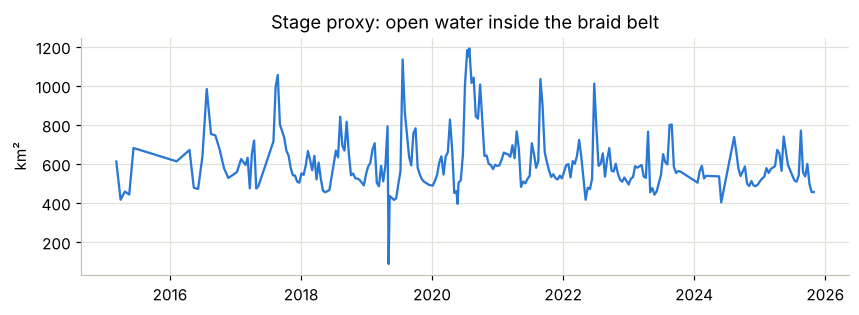

In [4]:
st = df.drop_duplicates("forecast_date")[["forecast_date", "stage_km2"]]
fig, ax = plt.subplots(figsize=(9, 2.8))
ax.plot(st.forecast_date, st.stage_km2, color=C1, lw=1.5)
ax.set_ylabel("km²"); ax.set_title("Stage proxy: open water inside the braid belt")
plt.show()

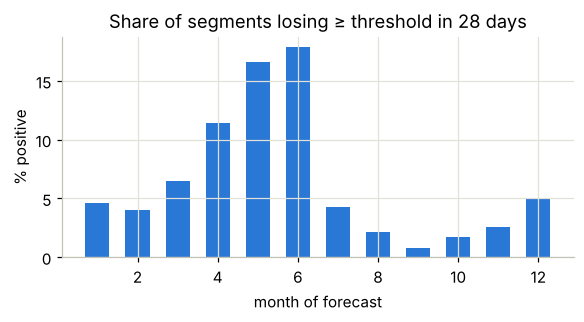

In [5]:
m = df.groupby(df.forecast_date.dt.month)["y"].mean()
fig, ax = plt.subplots(figsize=(6, 2.6)); ax.bar(m.index, m.values * 100, color=C1, width=0.6)
ax.set_xlabel("month of forecast"); ax.set_ylabel("% positive"); ax.set_title("Share of segments losing ≥ threshold in 28 days")
plt.show()